# Telco Customer Churn — Classification Project

**Author:** Zakee Ul Hassan
**Dataset:** [Telco Customer Churn (Kaggle)](https://www.kaggle.com/datasets/blastchar/telco-customer-churn) — 7,043 customers

**Goal:** Predict which customers will churn, identify the strongest churn drivers, and provide a business recommendation.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
df = pd.read_csv('../data/Telco-Customer-Churn.csv')
print("Data loaded successfully!")
print("Shape:",df.shape)

df.tail(10)

Data loaded successfully!
Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7033,9767-FFLEM,Male,0,No,No,38,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Credit card (automatic),69.50,2625.25,No
7034,0639-TSIQW,Female,0,No,No,67,Yes,Yes,Fiber optic,Yes,...,Yes,No,Yes,No,Month-to-month,Yes,Credit card (automatic),102.95,6886.25,Yes
7035,8456-QDAVC,Male,0,No,No,19,Yes,No,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Bank transfer (automatic),78.70,1495.1,No
7036,7750-EYXWZ,Female,0,No,No,12,No,No phone service,DSL,No,...,Yes,Yes,Yes,Yes,One year,No,Electronic check,60.65,743.3,No
7037,2569-WGERO,Female,0,No,No,72,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Bank transfer (automatic),21.15,1419.4,No
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


In [3]:
print("Churn distribution:")
print(df['Churn'].value_counts())
print("\nChurn rate (%):")
print(df['Churn'].value_counts(normalize=True) * 100)

Churn distribution:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn rate (%):
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


### Initial Observations

- **7,043 customers, 21 columns**, one ID (`customerID`), 19 features, and the target (`Churn`).
- **Class imbalance:** ~73% No, ~27% Yes (1,869 churners). This is significant accuracy alone will be misleading. Will need to track recall, precision, F1, and ROC-AUC.
- **`TotalCharges` is stored as `object`** (text), not numeric. Likely contains some empty strings or whitespace where total charges should be. Will need to clean and convert during preprocessing.
- **Mixed encoding for binary fields:** `SeniorCitizen` is already 0/1, but `Partner`, `Dependents`, `PaperlessBilling`, `Churn` are "Yes"/"No" strings. Will normalize during preprocessing.
- **Service columns have three values, not two** — many include "No internet service" in addition to Yes/No. Need to decide whether to treat as a third category or collapse to binary.
- **Tenure ranges 0 to 72 months** — note that 0-tenure customers may be brand-new and behave differently from established customers; worth checking churn rate by tenure later.

In [4]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors='coerce')
print("Data type of TotalCharges:", df["TotalCharges"].dtype)
print("Number of null values in TotalCharges:", df["TotalCharges"].isnull().sum())

Data type of TotalCharges: float64
Number of null values in TotalCharges: 11


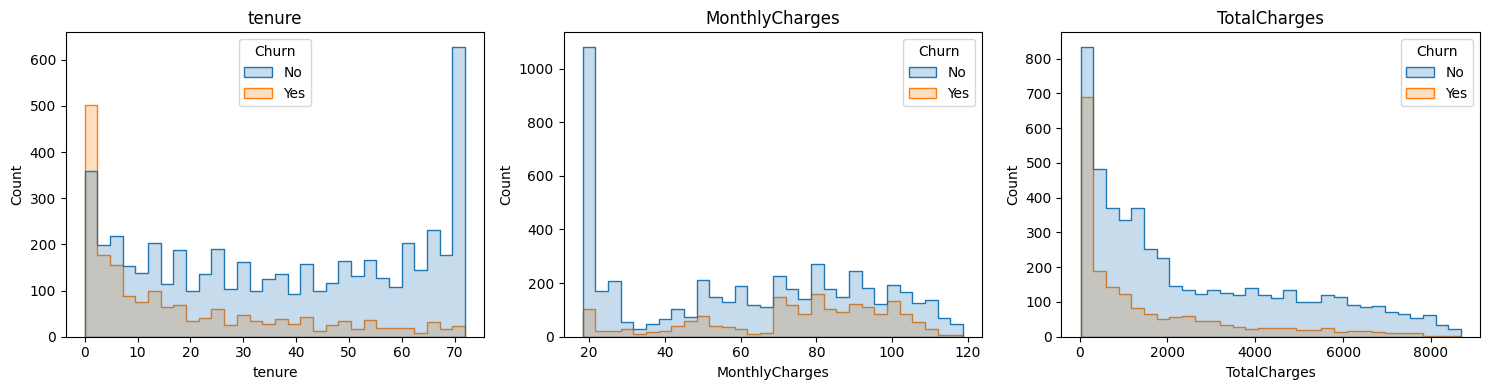

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, col in enumerate(['tenure', 'MonthlyCharges', 'TotalCharges']):
    sns.histplot(data=df, x=col, hue='Churn', bins=30, ax=axes[i], element='step')
    axes[i].set_title(col)

plt.tight_layout()
plt.savefig('../churn_distribution.png', dpi=100, bbox_inches='tight')
plt.show()

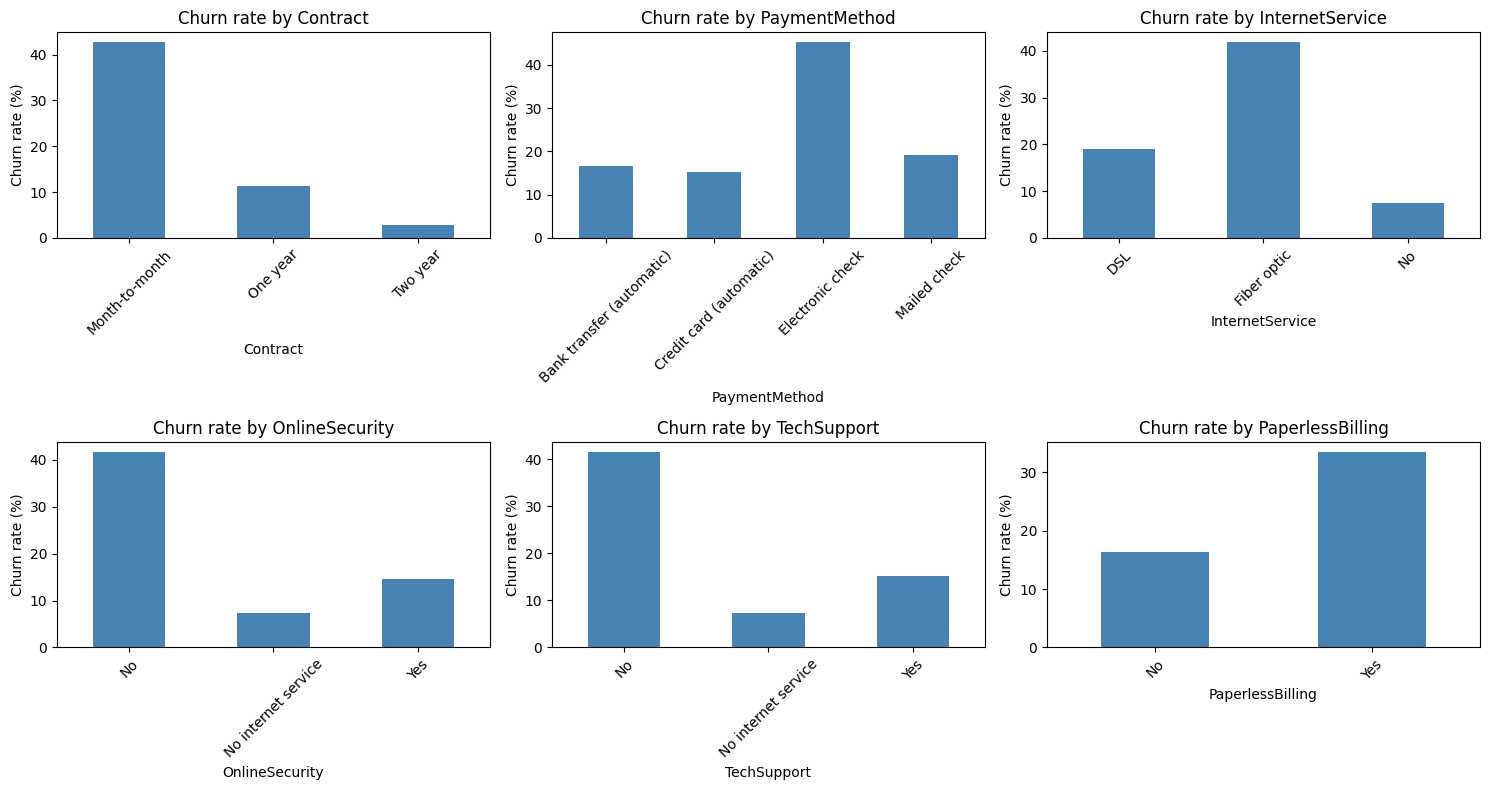

In [6]:
cat_cols = ['Contract', 'PaymentMethod', 'InternetService',
            'OnlineSecurity', 'TechSupport', 'PaperlessBilling']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()


for i, col in enumerate(cat_cols):
    churn_rate = df.groupby(col)['Churn'].apply(lambda x: (x == 'Yes').mean() * 100)
    churn_rate.plot(kind='bar', ax=axes[i], color='steelblue')
    axes[i].set_title(f'Churn rate by {col}')
    axes[i].set_ylabel('Churn rate (%)')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../churn_rates.png', dpi=100, bbox_inches='tight')
plt.show()

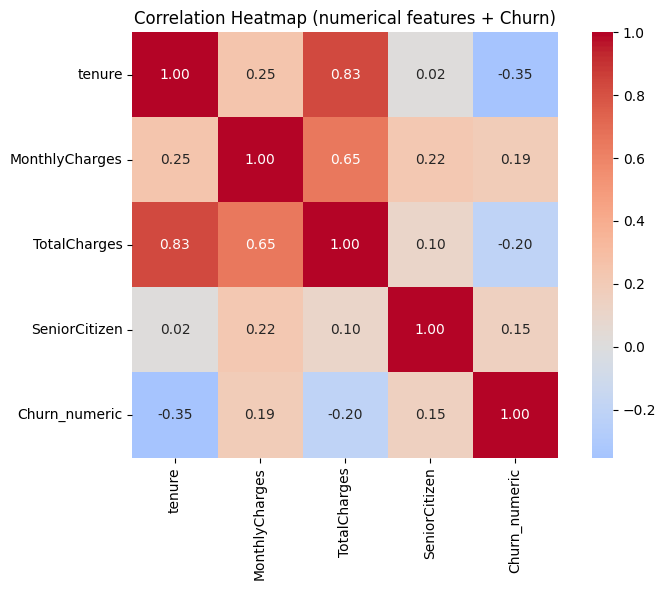

In [7]:
df['Churn_numeric'] = (df['Churn'] == 'Yes').astype(int)

numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges',
                'SeniorCitizen', 'Churn_numeric']

plt.figure(figsize=(8, 6))
sns.heatmap(df[numeric_cols].corr(),
            annot=True,
            cmap='coolwarm',
            center=0,
            fmt='.2f',
            square=True)
plt.title('Correlation Heatmap (numerical features + Churn)')
plt.tight_layout()
plt.savefig('../correlation_heatmap.png', dpi=100, bbox_inches='tight')
plt.show()

### EDA Findings Summary

**Strongest churn signals:**
- **Contract type** (categorical): month-to-month customers churn ~42%, two-year customers <3% — by far the biggest predictor.
- **tenure** (numeric): correlation of -0.35 with churn. Newer customers are much more likely to leave.
- **MonthlyCharges** (numeric): correlation of +0.19. Higher-paying customers churn slightly more.

**Categorical predictors with strong effects:**
- PaymentMethod (electronic check users churn ~45%)
- InternetService (fiber optic users churn more than DSL — counterintuitive)
- OnlineSecurity, TechSupport (customers without these add-ons churn 3-4× more)

**Weaker predictors, but kept for modeling:** PaperlessBilling, demographics. Whether they earn their keep will be decided by feature importance, not EDA.

**Multicollinearity warning:**
- `tenure` and `TotalCharges` are highly correlated (+0.83) since TotalCharges ≈ tenure × MonthlyCharges. May affect interpretability but tree-based models handle this fine.

**Data quality note:**
- 11 missing values in `TotalCharges` after numeric conversion — all corresponding to tenure=0 (brand-new customers). Will impute or drop during preprocessing.

In [8]:
df["TotalCharges"] = df["TotalCharges"].fillna(0)
df["TotalCharges"].isnull().sum()

np.int64(0)

In [9]:
df = df.drop(columns=['customerID', 'Churn_numeric'])
print("Shape after dropping ID:", df.shape)
print("Columns:", df.columns.tolist())


Shape after dropping ID: (7043, 20)
Columns: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [10]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [11]:
# Step 3a: Map binary Yes/No fields to 1/0
binary_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']
for col in binary_cols:
    df[col] = df[col].map({'Yes': 1, 'No': 0})
    
    # Step 3b: Map gender to 0/1 (just convention — Female=0, Male=1)
df['gender'] = df['gender'].map({'Female': 0, 'Male': 1})

# Step 3c: One-hot encode all remaining text columns
df = pd.get_dummies(df, drop_first=False)
# Convert any boolean columns from True/False to 1/0 (cleaner)
bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)

print("Shape after encoding:", df.shape)

print("\nFirst few columns:", df.columns[:10].tolist())

print("\nLast few columns:", df.columns[-10:].tolist())
print("\nAny non-numeric columns left?")
print(df.dtypes[df.dtypes == 'object'])

Shape after encoding: (7043, 41)

First few columns: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'Churn']

Last few columns: ['StreamingMovies_No', 'StreamingMovies_No internet service', 'StreamingMovies_Yes', 'Contract_Month-to-month', 'Contract_One year', 'Contract_Two year', 'PaymentMethod_Bank transfer (automatic)', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']

Any non-numeric columns left?
Series([], dtype: object)


In [12]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,StreamingMovies_No,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,1,29.85,29.85,0,...,1,0,0,1,0,0,0,0,1,0
1,1,0,0,0,34,1,0,56.95,1889.50,0,...,1,0,0,0,1,0,0,0,0,1
2,1,0,0,0,2,1,1,53.85,108.15,1,...,1,0,0,1,0,0,0,0,0,1
3,1,0,0,0,45,0,0,42.30,1840.75,0,...,1,0,0,0,1,0,1,0,0,0
4,0,0,0,0,2,1,1,70.70,151.65,1,...,1,0,0,1,0,0,0,0,1,0


In [14]:
from sklearn.model_selection import train_test_split

# Separate features (X) from target (y)
X = df.drop(columns=['Churn'])
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape, "→", y_train.shape)
print("Test set:    ", X_test.shape, "→", y_test.shape)
print()
print("Churn rate in training set:", round(y_train.mean() * 100, 2), "%")
print("Churn rate in test set:    ", round(y_test.mean() * 100, 2), "%")

Training set: (5634, 40) → (5634,)
Test set:     (1409, 40) → (1409,)

Churn rate in training set: 26.54 %
Churn rate in test set:     26.54 %


In [15]:
df.to_csv('../data/telco_preprocessed.csv', index=False)
print("Saved preprocessed dataset")

Saved preprocessed dataset


In [16]:
X_train.to_csv('../data/X_train.csv', index=False)
X_test.to_csv('../data/X_test.csv', index=False)
y_train.to_csv('../data/y_train.csv', index=False)
y_test.to_csv('../data/y_test.csv', index=False)
print("Saved train/test splits")

Saved train/test splits


In [20]:
from sklearn.preprocessing import StandardScaler

# Identify the numerical columns that need scaling
# (the encoded 0/1 columns don't really need scaling but won't be hurt)
numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

# Fit the scaler on training data only — never on test data!
scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test_scaled[numerical_cols] = scaler.transform(X_test[numerical_cols])

print("Numerical features scaled ✓")
print("\nBefore scaling (X_train['tenure'].describe()):")
print(X_train['tenure'].describe().round(2))
print("\nAfter scaling (X_train_scaled['tenure'].describe()):")
print(X_train_scaled['tenure'].describe().round(2))

Numerical features scaled ✓

Before scaling (X_train['tenure'].describe()):
count    5634.00
mean       32.49
std        24.57
min         0.00
25%         9.00
50%        29.00
75%        55.00
max        72.00
Name: tenure, dtype: float64

After scaling (X_train_scaled['tenure'].describe()):
count    5634.00
mean       -0.00
std         1.00
min        -1.32
25%        -0.96
50%        -0.14
75%         0.92
max         1.61
Name: tenure, dtype: float64


In [28]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)

y_pred_lr = log_reg.predict(X_test_scaled)
y_proba_lr = log_reg.predict_proba(X_test_scaled)[:, 1]

train_acc = log_reg.score(X_train_scaled, y_train)
test_acc = log_reg.score(X_test_scaled, y_test)

print(f"Training accuracy: {train_acc:.4f}")
print(f"Test accuracy:     {test_acc:.4f}")

Training accuracy: 0.8058
Test accuracy:     0.8055


In [29]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Compute all the key metrics
print("=== Logistic Regression Performance ===\n")

# Classification report — precision, recall, F1
print("Classification Report:")
print(classification_report(y_test, y_pred_lr, target_names=['Stay', 'Churn']))

# Confusion matrix
print("Confusion Matrix:")
cm = confusion_matrix(y_test, y_pred_lr)
print(f"                Predicted Stay  Predicted Churn")
print(f"Actual Stay     {cm[0,0]:>14}  {cm[0,1]:>15}")
print(f"Actual Churn    {cm[1,0]:>14}  {cm[1,1]:>15}")

# ROC-AUC
auc = roc_auc_score(y_test, y_proba_lr)
print(f"\nROC-AUC: {auc:.4f}")

=== Logistic Regression Performance ===

Classification Report:
              precision    recall  f1-score   support

        Stay       0.85      0.89      0.87      1035
       Churn       0.66      0.56      0.60       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409

Confusion Matrix:
                Predicted Stay  Predicted Churn
Actual Stay                926              109
Actual Churn               165              209

ROC-AUC: 0.8420


In [33]:
from sklearn.ensemble import RandomForestClassifier

rf_balanced = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
)

rf_balanced.fit(X_train, y_train)

y_pred_rf_bal = rf_balanced.predict(X_test)
y_proba_rf_bal = rf_balanced.predict_proba(X_test)[:, 1]

print("=== Random Forest (Balanced) Performance ===\n")

print("Classification Report:")
print(classification_report(y_test, y_pred_rf_bal, target_names=['Stay', 'Churn']))

print("Confusion Matrix:")
cm_rfb = confusion_matrix(y_test, y_pred_rf_bal)
print(f"                Predicted Stay  Predicted Churn")
print(f"Actual Stay     {cm_rfb[0,0]:>14}  {cm_rfb[0,1]:>15}")
print(f"Actual Churn    {cm_rfb[1,0]:>14}  {cm_rfb[1,1]:>15}")

auc_rfb = roc_auc_score(y_test, y_proba_rf_bal)
print(f"\nROC-AUC: {auc_rfb:.4f}")

=== Random Forest (Balanced) Performance ===

Classification Report:
              precision    recall  f1-score   support

        Stay       0.82      0.89      0.86      1035
       Churn       0.61      0.48      0.54       374

    accuracy                           0.78      1409
   macro avg       0.72      0.68      0.70      1409
weighted avg       0.77      0.78      0.77      1409

Confusion Matrix:
                Predicted Stay  Predicted Churn
Actual Stay                919              116
Actual Churn               195              179

ROC-AUC: 0.8232


In [34]:
from sklearn.ensemble import GradientBoostingClassifier

# Step 1: Instantiate
gb = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

# Step 2: Fit (no scaling needed — tree-based)
gb.fit(X_train, y_train)

# Step 3: Predict
y_pred_gb = gb.predict(X_test)
y_proba_gb = gb.predict_proba(X_test)[:, 1]

# Step 4: Evaluate
print("=== Gradient Boosting Performance ===\n")

print("Classification Report:")
print(classification_report(y_test, y_pred_gb, target_names=['Stay', 'Churn']))

print("Confusion Matrix:")
cm_gb = confusion_matrix(y_test, y_pred_gb)
print(f"                Predicted Stay  Predicted Churn")
print(f"Actual Stay     {cm_gb[0,0]:>14}  {cm_gb[0,1]:>15}")
print(f"Actual Churn    {cm_gb[1,0]:>14}  {cm_gb[1,1]:>15}")

auc_gb = roc_auc_score(y_test, y_proba_gb)
print(f"\nROC-AUC: {auc_gb:.4f}")

=== Gradient Boosting Performance ===

Classification Report:
              precision    recall  f1-score   support

        Stay       0.84      0.89      0.86      1035
       Churn       0.63      0.51      0.57       374

    accuracy                           0.79      1409
   macro avg       0.73      0.70      0.72      1409
weighted avg       0.78      0.79      0.78      1409

Confusion Matrix:
                Predicted Stay  Predicted Churn
Actual Stay                924              111
Actual Churn               182              192

ROC-AUC: 0.8351


In [39]:
# Get the coefficients
coefs = pd.DataFrame({
    'feature': X_train.columns,
    'coefficient': log_reg.coef_[0]
})

# Sort by absolute value to find strongest effects
coefs['abs_coef'] = coefs['coefficient'].abs()
coefs = coefs.sort_values('abs_coef', ascending=False)

# Top 15 most influential features
print("Top 15 strongest predictors of Churn:")
print(coefs[['feature', 'coefficient']].head(15).to_string(index=False))

Top 15 strongest predictors of Churn:
                             feature  coefficient
                              tenure    -1.243783
                   Contract_Two year    -0.815464
                 InternetService_DSL    -0.701492
                      MonthlyCharges    -0.599561
         InternetService_Fiber optic     0.594133
             Contract_Month-to-month     0.529294
                        TotalCharges     0.520075
                    PaperlessBilling     0.370498
     StreamingTV_No internet service    -0.349469
     TechSupport_No internet service    -0.349469
  OnlineSecurity_No internet service    -0.349469
 StreamingMovies_No internet service    -0.349469
    OnlineBackup_No internet service    -0.349469
DeviceProtection_No internet service    -0.349469
                  InternetService_No    -0.349469


In [40]:
# Build a clean comparison table
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest (default)',
              'Random Forest (balanced)', 'Gradient Boosting'],
    'ROC-AUC': [0.8420, 0.8196, 0.8232, 0.8351],
    'Accuracy': [0.81, 0.78, 0.78, 0.79],
    'Precision (Churn)': [0.66, 0.61, 0.61, 0.63],
    'Recall (Churn)': [0.56, 0.49, 0.48, 0.51],
    'F1 (Churn)': [0.60, 0.55, 0.54, 0.57]
})

# Highlight our chosen model
print("Model Comparison (sorted by F1 on Churn class):")
print(results.sort_values('F1 (Churn)', ascending=False).to_string(index=False))

Model Comparison (sorted by F1 on Churn class):
                   Model  ROC-AUC  Accuracy  Precision (Churn)  Recall (Churn)  F1 (Churn)
     Logistic Regression   0.8420      0.81               0.66            0.56        0.60
       Gradient Boosting   0.8351      0.79               0.63            0.51        0.57
 Random Forest (default)   0.8196      0.78               0.61            0.49        0.55
Random Forest (balanced)   0.8232      0.78               0.61            0.48        0.54


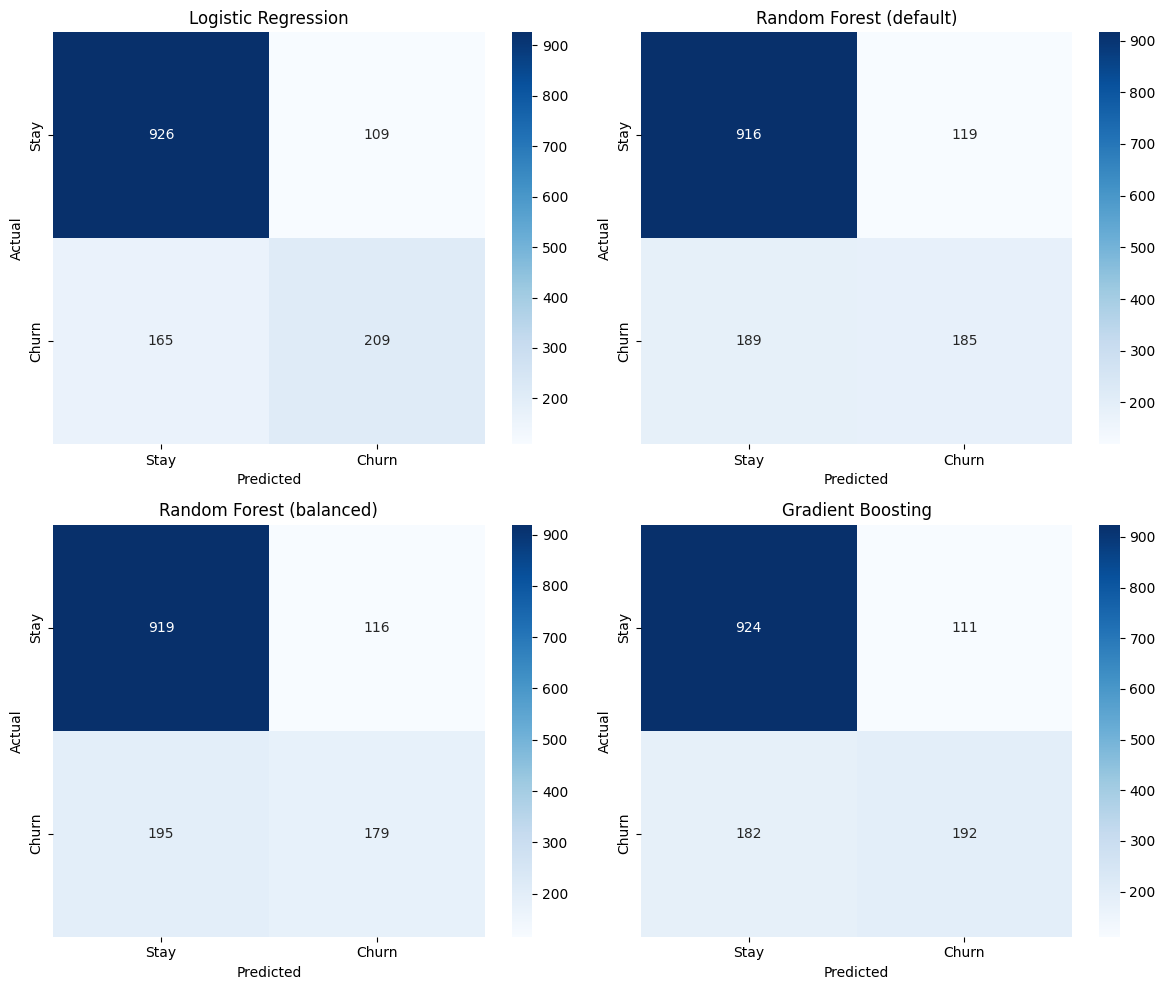

In [44]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Build a 2x2 grid of confusion matrices
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

# Pair each model's predictions with a label
models = [
    ('Logistic Regression', y_pred_lr),
    ('Random Forest (default)', y_pred_rf),
    ('Random Forest (balanced)', y_pred_rf_bal),
    ('Gradient Boosting', y_pred_gb)
]

for i, (name, y_pred) in enumerate(models):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        ax=axes[i],
        xticklabels=['Stay', 'Churn'],
        yticklabels=['Stay', 'Churn']
    )
    axes[i].set_title(name)
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')

plt.tight_layout()
plt.savefig('../confusion_matrices.png', dpi=100, bbox_inches='tight')
plt.show()

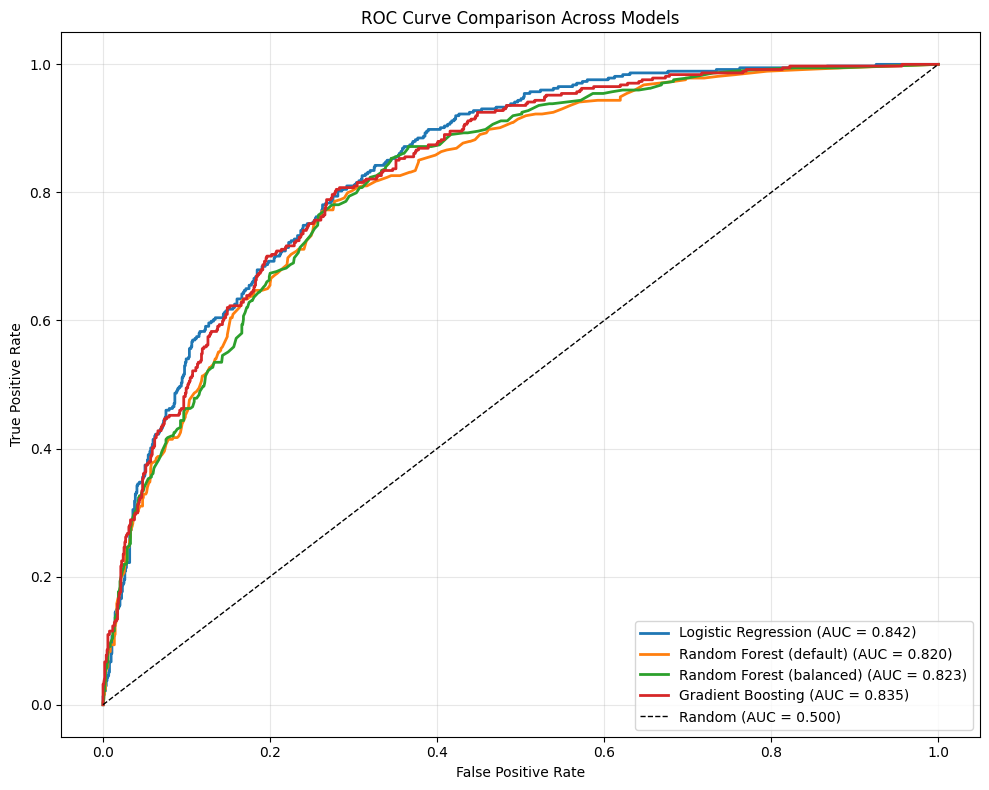

In [45]:
from sklearn.metrics import roc_curve, roc_auc_score

plt.figure(figsize=(10, 8))

# Each model's probability scores
models_proba = [
    ('Logistic Regression', y_proba_lr),
    ('Random Forest (default)', y_proba_rf),
    ('Random Forest (balanced)', y_proba_rf_bal),
    ('Gradient Boosting', y_proba_gb)
]

for name, y_proba in models_proba:
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, linewidth=2, label=f'{name} (AUC = {auc:.3f})')

# Add the diagonal (random-guessing baseline)
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random (AUC = 0.500)')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison Across Models')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../roc_curves.png', dpi=100, bbox_inches='tight')
plt.show()

### Observations from Visual Evaluation

- All four models produce ROC curves clearly above the random-guessing diagonal — each captures real signal.
- Logistic Regression's curve hugs the top-left corner most tightly, consistent with its highest AUC (0.842).
- Confusion matrices reveal all models share the same struggle: catching the minority class (Churn). Around 40-45% of real churners are missed at the default 0.5 threshold across all models.
- For deployment, lowering the threshold to ~0.35 would shift more predictions toward Churn, increasing recall (catching more churners) at the cost of more false alarms — appropriate when the cost of a missed churner exceeds a wasted retention offer.

In [ ]:
# STEP 1: Pair every test customer's churn probability with their actual churn label
results_df = pd.DataFrame({
    'churn_probability': y_proba_lr,    # the model's prediction
    'actual_churn': y_test.values        # what really happened
})

# STEP 2: Sort customers from highest to lowest predicted churn probability
# (so the "riskiest" customer is at row 0, "safest" at the bottom)
results_df = results_df.sort_values('churn_probability', ascending=False).reset_index(drop=True)

# STEP 3: Total churners in the entire test set (all 374 of them)
total_churners = results_df['actual_churn'].sum()

# STEP 4: Print a header for the table
print(f"{'Top X%':<10}{'Customers':<12}{'Churners Caught':<18}{'% of All Churners':<20}{'Multiplier':<12}")
print("-" * 72)

# STEP 5: For different "target the top X%" strategies, count how many churners we catch
for pct in [5, 10, 20, 30, 50, 100]:
    # How many customers does "top X%" contain?
    n_targeted = int(len(results_df) * pct / 100)
    
    # Of the top X%, how many were actually churners?
    churners_caught = results_df.head(n_targeted)['actual_churn'].sum()
    
    # What % of ALL churners did we catch?
    pct_of_churners = churners_caught / total_churners * 100
    
    # How much better than random? (random would catch X% of churners by targeting X% of customers)
    multiplier = pct_of_churners / pct
    
    print(f"{pct:<10}{n_targeted:<12}{churners_caught:<18}{pct_of_churners:<20.1f}{multiplier:<12.2f}")

Targeting Strategy: How many churners caught by contacting top X%?

Top X%    Customers   Churners Caught   % of All Churners   Multiplier  
------------------------------------------------------------------------
5         70          54                14.4                2.89        
10        140         105               28.1                2.81        
20        281         186               49.7                2.49        
30        422         243               65.0                2.17        
50        704         326               87.2                1.74        
100       1409        374               100.0               1.00        


---

## Business Recommendation

The Logistic Regression model produces actionable customer-level churn risk scores. Here's how the telco could use it:

### Strategic Targeting Recommendation

| Strategy | Customers contacted | Churners caught | % of all churners | Lift vs random |
|---|---|---|---|---|
| Top 5% riskiest | 70 | 54 | 14.4% | **2.89×** |
| Top 10% riskiest | 140 | 105 | 28.1% | **2.81×** |
| Top 20% riskiest | 281 | 186 | **49.7%** | **2.49×** |
| Top 30% riskiest | 422 | 243 | 65.0% | 2.17× |
| Top 50% riskiest | 704 | 326 | 87.2% | 1.74× |

**Recommended deployment:** Target the top 20-30% riskiest customers. This catches 50-65% of all churners using only a fraction of the retention budget — a 2.2-2.5× improvement over random outreach.

### Where to Look for Churn Drivers

Based on Logistic Regression coefficients (validated against EDA findings):

1. **Contract structure is the dominant lever.** Two-year contract customers churn dramatically less than month-to-month customers. The clearest single retention strategy: incentivize longer commitments.

2. **Tenure compounds loyalty.** Each additional standard deviation of tenure reduces predicted churn substantially. Investing in customer experience during the first 12 months has outsized returns.

3. **Fiber optic customers are at-risk despite being premium.** This counterintuitive finding — fiber customers churn *more* than DSL — suggests a service-quality or competitive-pricing issue worth investigating.

4. **Service add-ons act as retention anchors.** Customers without OnlineSecurity or TechSupport churn 3-4× more. Bundling these by default could improve retention.

5. **Electronic check users churn more than other payment methods.** Likely a friction signal — manual payment requires deliberate action each cycle, creating natural exit moments.

### Limitations

- The "canceled" status used here is narrow; some functional cancellations (unavailable, undelivered) may be coded differently.
- LogReg coefficients should be read with care given multicollinearity (notably tenure ↔ TotalCharges at 0.83 and MonthlyCharges ↔ Fiber optic).
- Default 0.5 threshold yields recall of 0.56. For deployment, lowering the threshold to ~0.35 would trade precision for recall, appropriate when missing a churner costs more than wasting a retention offer.
- Dataset spans a single time window; multi-year data would strengthen confidence in the seasonal effects flagged in EDA.